In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 44.2 MB/s eta 0:00:00


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
import seaborn as sns
import jax;

jax.config.update('jax_platform_name', 'cpu')
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import optax  # optimization using jax

import pennylane as qml
import pennylane.numpy as pnp

sns.set()

seed = 0
rng = np.random.default_rng(seed=seed)

In [ ]:
def convolutional_layer(weights, wires, skip_first_layer=True):
    """Adds a convolutional layer to a circuit.
    Args:
        weights (np.array): 1D array with 15 weights of the parametrized gates.
        wires (list[int]): Wires where the convolutional layer acts on.
        skip_first_layer (bool): Skips the first two U3 gates of a layer.
    """
    #Wires are the Qubits or To be more Precise
    #Wires is a list representing the qubits (quantum wires) on which the quantum operations will be applied [0,1,2,3,4,5].
    #Weights are the Paramteres or numerical values that define the behaviour of the Quantum Gates
    #len(wires) is the number of qubits
    n_wires = len(wires)
    assert n_wires >= 3, "this circuit is too small!" #If Number of Qubits is less than 3 then print that statement


#p here means how many qubits do you want to perform operations on together i.e in this case 2 adjacent qubits
#indx: This variable holds the index of the current item in the wires list.
#w: This variable represents the value of the current item in the wires list, which in this case, corresponds to the qubit (or wire) number.
    for p in [0,1]:
        for indx, w in enumerate(wires):
            if indx % 2 == p and indx < n_wires - 1:
                if indx % 2 == 0 and not skip_first_layer:
                    qml.U3(*weights[:3], wires=[w])
                    qml.U3(*weights[3:6], wires=[wires[indx + 1]])
                qml.IsingXX(weights[6], wires=[w, wires[indx + 1]])
                qml.IsingYY(weights[7], wires=[w, wires[indx + 1]])
                qml.IsingZZ(weights[8], wires=[w, wires[indx + 1]])
                qml.U3(*weights[9:12], wires=[w])
                qml.U3(*weights[12:], wires=[wires[indx + 1]])

In [ ]:
def pooling_layer(weights, wires):
    """Adds a pooling layer to a circuit.
    Args:
        weights (np.array): Array with the weights of the conditional U3 gate.
        wires (list[int]): List of wires to apply the pooling layer on.
    """
    n_wires = len(wires)
    assert len(wires) >= 2, "this circuit is too small!"

    for indx, w in enumerate(wires):
        if indx % 2 == 1 and indx < n_wires:
            m_outcome = qml.measure(w) #Collapses the qubit's state into either 0 or 1 i.e into a classical state by measuring it
            qml.cond(m_outcome, qml.U3)(*weights, wires=wires[indx - 1]) #If m_outcome is 1 qml.U3 will be applied

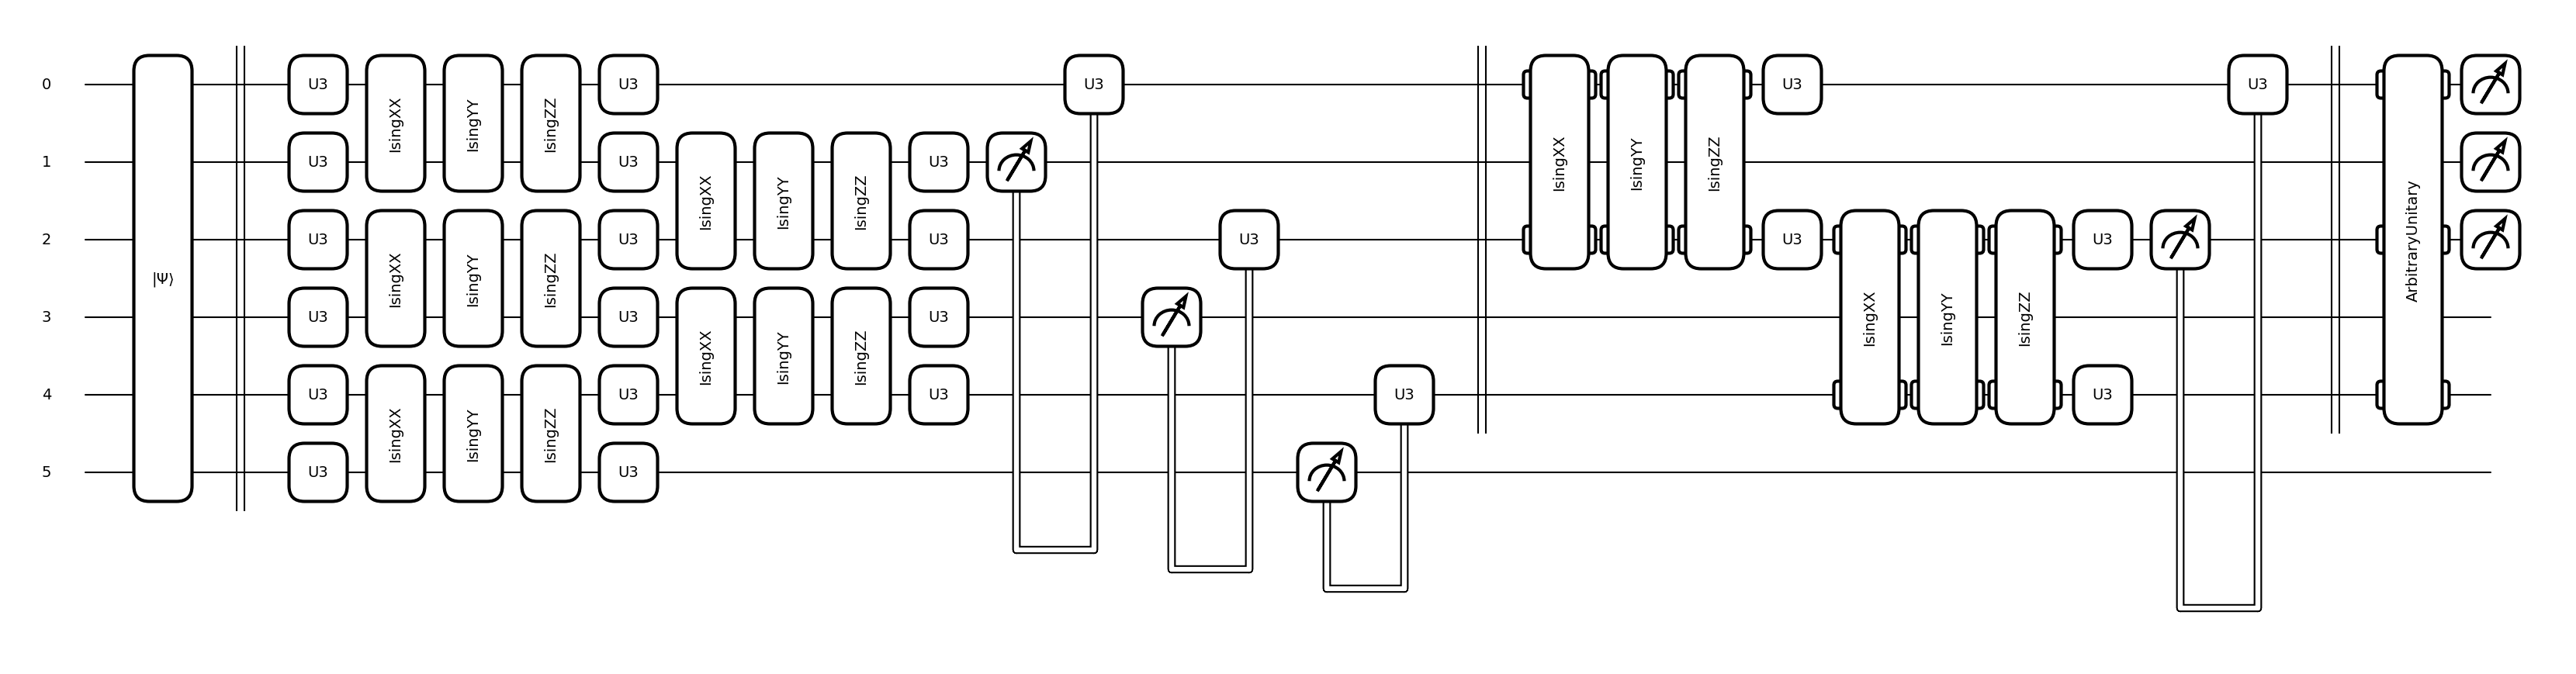

In [ ]:
def conv_and_pooling(kernel_weights, n_wires, skip_first_layer=True):
    """Apply both the convolutional and pooling layer."""
    convolutional_layer(kernel_weights[:15], n_wires, skip_first_layer=skip_first_layer)
    pooling_layer(kernel_weights[15:], n_wires)


def dense_layer(weights, wires):
    """Apply an arbitrary unitary gate to a specified set of wires."""
    qml.ArbitraryUnitary(weights, wires)


num_wires = 6
device = qml.device("default.qubit", wires=num_wires)
"""
1. qml.device(): This is a function provided by PennyLane (Quantum Machine Learning Library)
used to define the computational device or backend on which the quantum circuit will be executed.
2. "default.qubit": This is the name of the backend or device that you want to use. In this case,
"default.qubit" refers to the default qubit simulator provided by PennyLane. It simulates quantum computations using qubits.
3. wires=num_wires: This parameter specifies the number of qubits or quantum wires that will
be used in the quantum circuit. The num_wires variable is passed as the value here.
"""

@qml.qnode(device)
def conv_net(weights, last_layer_weights, features):
    """Define the QCNN circuit
    Args:
        weights (np.array): Parameters of the convolution and pool layers.
        last_layer_weights (np.array): Parameters of the last dense layer.
        features (np.array): Input data to be embedded using AmplitudEmbedding."""

    layers = weights.shape[1]
    wires = list(range(num_wires))

    # inputs the state input_state
    qml.AmplitudeEmbedding(features=features, wires=wires, pad_with=0.5)
    qml.Barrier(wires=wires, only_visual=True)

    # adds convolutional and pooling layers

    for j in range(layers):
        conv_and_pooling(weights[:, j], wires, skip_first_layer=(not j == 0))
        while len(wires)>3:
          wires = wires[::2]  #Half the number of qubits after each layer

        qml.Barrier(wires=wires, only_visual=True)

    assert last_layer_weights.size == 4 ** (len(wires)) - 1, (
        "The size of the last layer weights vector is incorrect!"
        f" \n Expected {4 ** (len(wires)) - 1}, Given {last_layer_weights.size}"
    )
    dense_layer(last_layer_weights, wires)
    return qml.probs(wires=[0,1,2])


fig, ax = qml.draw_mpl(conv_net)(
    np.random.rand(18, 2), np.random.rand(4 ** 3 - 1), np.random.rand(2 ** num_wires)
)
plt.show()

float64
[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
[0 1 2 ... 8 9 8]
int64


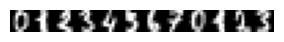

In [ ]:
digits = datasets.load_digits()
images, labels = digits.data, digits.target

print(images.dtype)
print(images)
print(labels)
print(labels.dtype)
images = images[np.where((labels == 0) | (labels == 1) | (labels ==2) | (labels == 3) | (labels == 4) | (labels == 5) | (labels == 6) | (labels == 7)) ]
labels = labels[np.where((labels == 0) | (labels == 1) | (labels ==2) | (labels == 3) | (labels == 4) | (labels == 5) | (labels == 6) | (labels == 7)) ]

fig, axes = plt.subplots(nrows=1, ncols=12, figsize=(3, 1))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i].reshape((8, 8)), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()


In [ ]:
def load_digits_data(num_train, num_test, rng):
    """Return training and testing data of digits dataset."""
    digits = datasets.load_digits()
    features, labels = digits.data, digits.target

    # only use first two classes
    features = features[np.where((labels == 0) | (labels == 1) | (labels ==2) | (labels == 3) | (labels == 4) | (labels == 5) | (labels == 6) | (labels == 7)) ]
    labels = labels[np.where((labels == 0) | (labels == 1) | (labels ==2) | (labels == 3) | (labels == 4) | (labels == 5) | (labels == 6) | (labels == 7)) ]

    # normalize data
    features = features / np.linalg.norm(features, axis=1).reshape((-1, 1))

    # subsample train and test split
    train_indices = rng.choice(len(labels), num_train, replace=False) #Selects num_train number of indices in the range 0 and len(labels)
    test_indices = rng.choice(
        np.setdiff1d(range(len(labels)), train_indices), num_test, replace=False  #Selects The Set differece of the total indices and the train indices and assigns them to the test indices
    )

    x_train, y_train = features[train_indices], labels[train_indices]
    x_test, y_test = features[test_indices], labels[test_indices]

    return (
        jnp.asarray(x_train),
        jnp.asarray(y_train),
        jnp.asarray(x_test),
        jnp.asarray(y_test),
    )

In [ ]:
@jax.jit
def compute_out(weights, weights_last, features, labels):
    """Computes the output of the corresponding label in the qcnn"""
    output_probabilities = jax.nn.softmax(conv_net(weights, weights_last, features))
    return output_probabilities


def compute_accuracy(weights, weights_last, features, labels):
    """Computes the accuracy over the provided features and labels"""
    out_probs = compute_out(weights, weights_last, features, labels)

    # Predicted classes are the argmax of the output probabilities
    predicted_classes = jnp.argmax(out_probs, axis=1)

    # Calculate accuracy by comparing predicted classes to true labels
    correct_predictions = jnp.sum(predicted_classes == labels)
    total_samples = len(labels)
    accuracy = correct_predictions / total_samples

    return accuracy


def compute_cost(weights, weights_last, features, labels):
    """Computes the categorical cross-entropy cost over the provided features and labels"""
    out_probs = compute_out(weights, weights_last, features, labels)

    # One-hot encode the labels
    num_classes = out_probs.shape[1]
    labels_one_hot = jnp.eye(num_classes)[labels]

    # Compute the categorical cross-entropy loss
    loss = -jnp.sum(labels_one_hot * jnp.log(out_probs + 1e-9))  # Adding a small value to prevent log(0)
    avg_loss = loss / len(labels)

    return avg_loss

def init_weights():
    """Initializes random weights for the QCNN model."""
    weights = pnp.random.normal(loc=0, scale=1, size=(18, 2), requires_grad=True)
    weights_last = pnp.random.normal(loc=0, scale=1, size=4 ** 3 - 1, requires_grad=True)
    return jnp.array(weights), jnp.array(weights_last)


value_and_grad = jax.jit(jax.value_and_grad(compute_cost, argnums=[0, 1]))

In [ ]:
def train_qcnn(n_train, n_test, n_epochs):
    """
    Args:
        n_train  (int): number of training examples
        n_test   (int): number of test examples
        n_epochs (int): number of training epochs
        desc  (string): displayed string during optimization

    Returns:
        dict: n_train,
        steps,
        train_cost_epochs,
        train_acc_epochs,
        test_cost_epochs,
        test_acc_epochs

    """
    # load data
    x_train, y_train, x_test, y_test = load_digits_data(n_train, n_test, rng)

    # init weights and optimizer
    weights, weights_last = init_weights()

    # learning rate decay
    cosine_decay_scheduler = optax.cosine_decay_schedule(0.1, decay_steps=n_epochs, alpha=0.95)
    optimizer = optax.adam(learning_rate=cosine_decay_scheduler)
    opt_state = optimizer.init((weights, weights_last))

    # data containers
    train_cost_epochs, test_cost_epochs, train_acc_epochs, test_acc_epochs = [], [], [], []

    for step in range(n_epochs):
        # Training step with (adam) optimizer
        train_cost, grad_circuit = value_and_grad(weights, weights_last, x_train, y_train)
        updates, opt_state = optimizer.update(grad_circuit, opt_state)
        weights, weights_last = optax.apply_updates((weights, weights_last), updates)
        train_cost_epochs.append(train_cost)

        # compute accuracy on training data
        train_acc = compute_accuracy(weights, weights_last, x_train, y_train)
        train_acc_epochs.append(train_acc)

        # compute accuracy and cost on testing data
        test_out = compute_out(weights, weights_last, x_test, y_test)
        predicted_labels = jnp.argmax(test_out, axis=1)  # Get predicted labels
        correct_predictions = predicted_labels == y_test  # Compare with true labels
        test_acc = jnp.mean(correct_predictions)  # Calculate accuracy
        test_acc_epochs.append(test_acc)
        test_cost = compute_cost(weights, weights_last, x_test, y_test)
        test_cost_epochs.append(test_cost)

    # Ensure all arrays have the same length
    assert len(train_cost_epochs) == len(train_acc_epochs) == len(test_cost_epochs) == len(test_acc_epochs) == n_epochs, \
        "Inconsistent lengths detected in epoch data arrays."

    return dict(
        n_train=[n_train] * n_epochs,
        step=np.arange(1, n_epochs + 1, dtype=int),
        train_acc=train_acc_epochs,
        test_acc=test_acc_epochs,
        train_cost = train_cost_epochs,
        test_cost = test_cost_epochs
    )

In [ ]:
n_test = 100
n_epochs = 100
n_reps = 100


def run_iterations(n_train):
    results_df = pd.DataFrame(
        columns=["train_acc", "test_acc", "step", "n_train"]
    )

    for _ in range(n_reps):
        results = train_qcnn(n_train=n_train, n_test=n_test, n_epochs=n_epochs)
        results_df = pd.concat(
            [results_df, pd.DataFrame.from_dict(results)], axis=0, ignore_index=True
        )

    return results_df


# run training for multiple sizes
train_sizes = [2,160,250,500]
results_df = run_iterations(n_train=2)
for n_train in train_sizes[1:]:
    results_df = pd.concat([results_df, run_iterations(n_train=n_train)])

In [ ]:
mean_accuracies = results_df.groupby('n_train').mean()[['train_acc', 'test_acc']]
print(mean_accuracies)

        train_acc  test_acc
n_train                    
2          0.9285  0.184898
160      0.476304  0.398506
250      0.508535  0.466047
500       0.52248  0.497148


In [ ]:
# aggregate dataframe
df_agg = results_df.groupby(["n_train", "step"]).agg(["mean", "std"])
df_agg = df_agg.reset_index()

sns.set_style('whitegrid')
colors = sns.color_palette()
fig, axes = plt.subplots(ncols=3, figsize=(16.5, 5))

generalization_errors = []

# plot losses and accuracies
for i, n_train in enumerate(train_sizes):
    df = df_agg[df_agg.n_train == n_train]

    dfs = [df.train_cost["mean"], df.test_cost["mean"], df.train_acc["mean"], df.test_acc["mean"]]
    lines = ["o-", "x--", "o-", "x--"]
    labels = [fr"$N={n_train}$", None, fr"$N={n_train}$", None]
    axs = [0,0,2,2]

    for k in range(4):
        ax = axes[axs[k]]
        ax.plot(df.step, dfs[k], lines[k], label=labels[k], markevery=10, color=colors[i], alpha=0.8)


    # plot final loss difference
    dif = df[df.step == 100].test_cost["mean"] - df[df.step == 100].train_cost["mean"]
    generalization_errors.append(dif)

# format loss plot
ax = axes[0]
ax.set_title('Train and Test Losses', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

# format generalization error plot
ax = axes[1]
ax.plot(train_sizes, generalization_errors, "o-", label=r"$gen(\alpha)$")
ax.set_xscale('log')
ax.set_xticks(train_sizes)
ax.set_xticklabels(train_sizes)
ax.set_title(r'Generalization Error $gen(\alpha) = R(\alpha) - \hat{R}_N(\alpha)$', fontsize=14)
ax.set_xlabel('Training Set Size')

# format loss plot
ax = axes[2]
ax.set_title('Train and Test Accuracies', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.05)

legend_elements = [
    mpl.lines.Line2D([0], [0], label=f'N={n}', color=colors[i]) for i, n in enumerate(train_sizes)
    ] + [
    mpl.lines.Line2D([0], [0], marker='o', ls='-', label='Train', color='Black'),
    mpl.lines.Line2D([0], [0], marker='x', ls='--', label='Test', color='Black')
    ]

axes[0].legend(handles=legend_elements, ncol=3)
axes[2].legend(handles=legend_elements, ncol=3)

axes[1].set_yscale('log', base=2)
plt.show()